Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#  Konfigurasi visual
PALETTE = {
    'normal'       : '#3498db',
    'early_stage'  : '#f1c40f',
    'escalating'   : '#e67e22',
    'heavy_gambler': '#e74c3c'
}
sns.set_style("whitegrid")
plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})

SECTION 1 — LOAD DATA & VALIDASI AWAL

In [1]:
file_path = "/content/judolguard_.csv"
df = pd.read_csv(file_path)

print("DATA OVERVIEW")
print(f"  Shape       : {df.shape[0]:,} baris × {df.shape[1]} kolom")
print(f"  Akun unik   : {df['account_id'].nunique()}")
print(f"  Profil      : {sorted(df['profile'].unique())}")
print(f"\n  Missing values: {df.isnull().sum().sum()} (harus 0)")



NameError: name 'pd' is not defined

In [ ]:
# Distribusi label — ini justifikasi kenapa pakai PR-AUC bukan accuracy
fraud_rate = df['is_at_risk'].mean() * 100
print(f"\n  Label distribusi:")
print(f"    At Risk  (1): {df['is_at_risk'].sum():,} ({fraud_rate:.1f}%)")
print(f"    Normal   (0): {(~df['is_at_risk'].astype(bool)).sum():,} ({100-fraud_rate:.1f}%)")


  Label distribusi:
    At Risk  (1): 15,128 (61.2%)
    Normal   (0): 9,610 (38.8%)


In [ ]:
# JUSTIFIKASI METRIK — ini yang dimasukkan ke notebook sebagai narasi
# fraud_rate is calculated in the previous cell based on 'is_at_risk'
if abs(fraud_rate - 50) > 10:
    print(f"\n  [JUSTIFIKASI METRIK]")
    print(f"  Data tidak seimbang ({fraud_rate:.0f}% vs {100-fraud_rate:.0f}%)")
    print(f"  → Metrik utama: PR-AUC & F1-Score (bukan Accuracy)")
    print(f"  → Accuracy bisa menyesatkan pada data imbalanced")


  [JUSTIFIKASI METRIK]
  Data tidak seimbang (61% vs 39%)
  → Metrik utama: PR-AUC & F1-Score (bukan Accuracy)
  → Accuracy bisa menyesatkan pada data imbalanced


In [ ]:
# Distribusi per profil
print(f"\n  Distribusi per profil:")
for p, g in df.groupby('profile'):
    n_acc = g['account_id'].nunique()
    n_tx  = len(g)
    label = "AT RISK" if g['is_at_risk'].iloc[0] == 1 else "NORMAL "
    print(f"    {p:<18} {n_acc:>4} akun | {n_tx:>6} transaksi | {label}")


  Distribusi per profil:
    early_stage         155 akun |   5301 transaksi | NORMAL 
    escalating          155 akun |   8215 transaksi | AT RISK
    heavy_gambler       155 akun |   6913 transaksi | AT RISK
    normal              155 akun |   4309 transaksi | NORMAL 


In [ ]:
# Distribusi per profil
print(f"\n  Distribusi per profil:")
for p, g in df.groupby('profile'):
    n_acc = g['account_id'].nunique()
    n_tx  = len(g)
    label = "AT RISK" if g['is_at_risk'].iloc[0] == 1 else "NORMAL "
    print(f"    {p:<18} {n_acc:>4} akun | {n_tx:>6} transaksi | {label}")


  Distribusi per profil:
    early_stage         155 akun |   5301 transaksi | NORMAL 
    escalating          155 akun |   8215 transaksi | AT RISK
    heavy_gambler       155 akun |   6913 transaksi | AT RISK
    normal              155 akun |   4309 transaksi | NORMAL 


SECTION 2 — VISUALISASI BEHAVIORAL SHIFT (6 CHART)

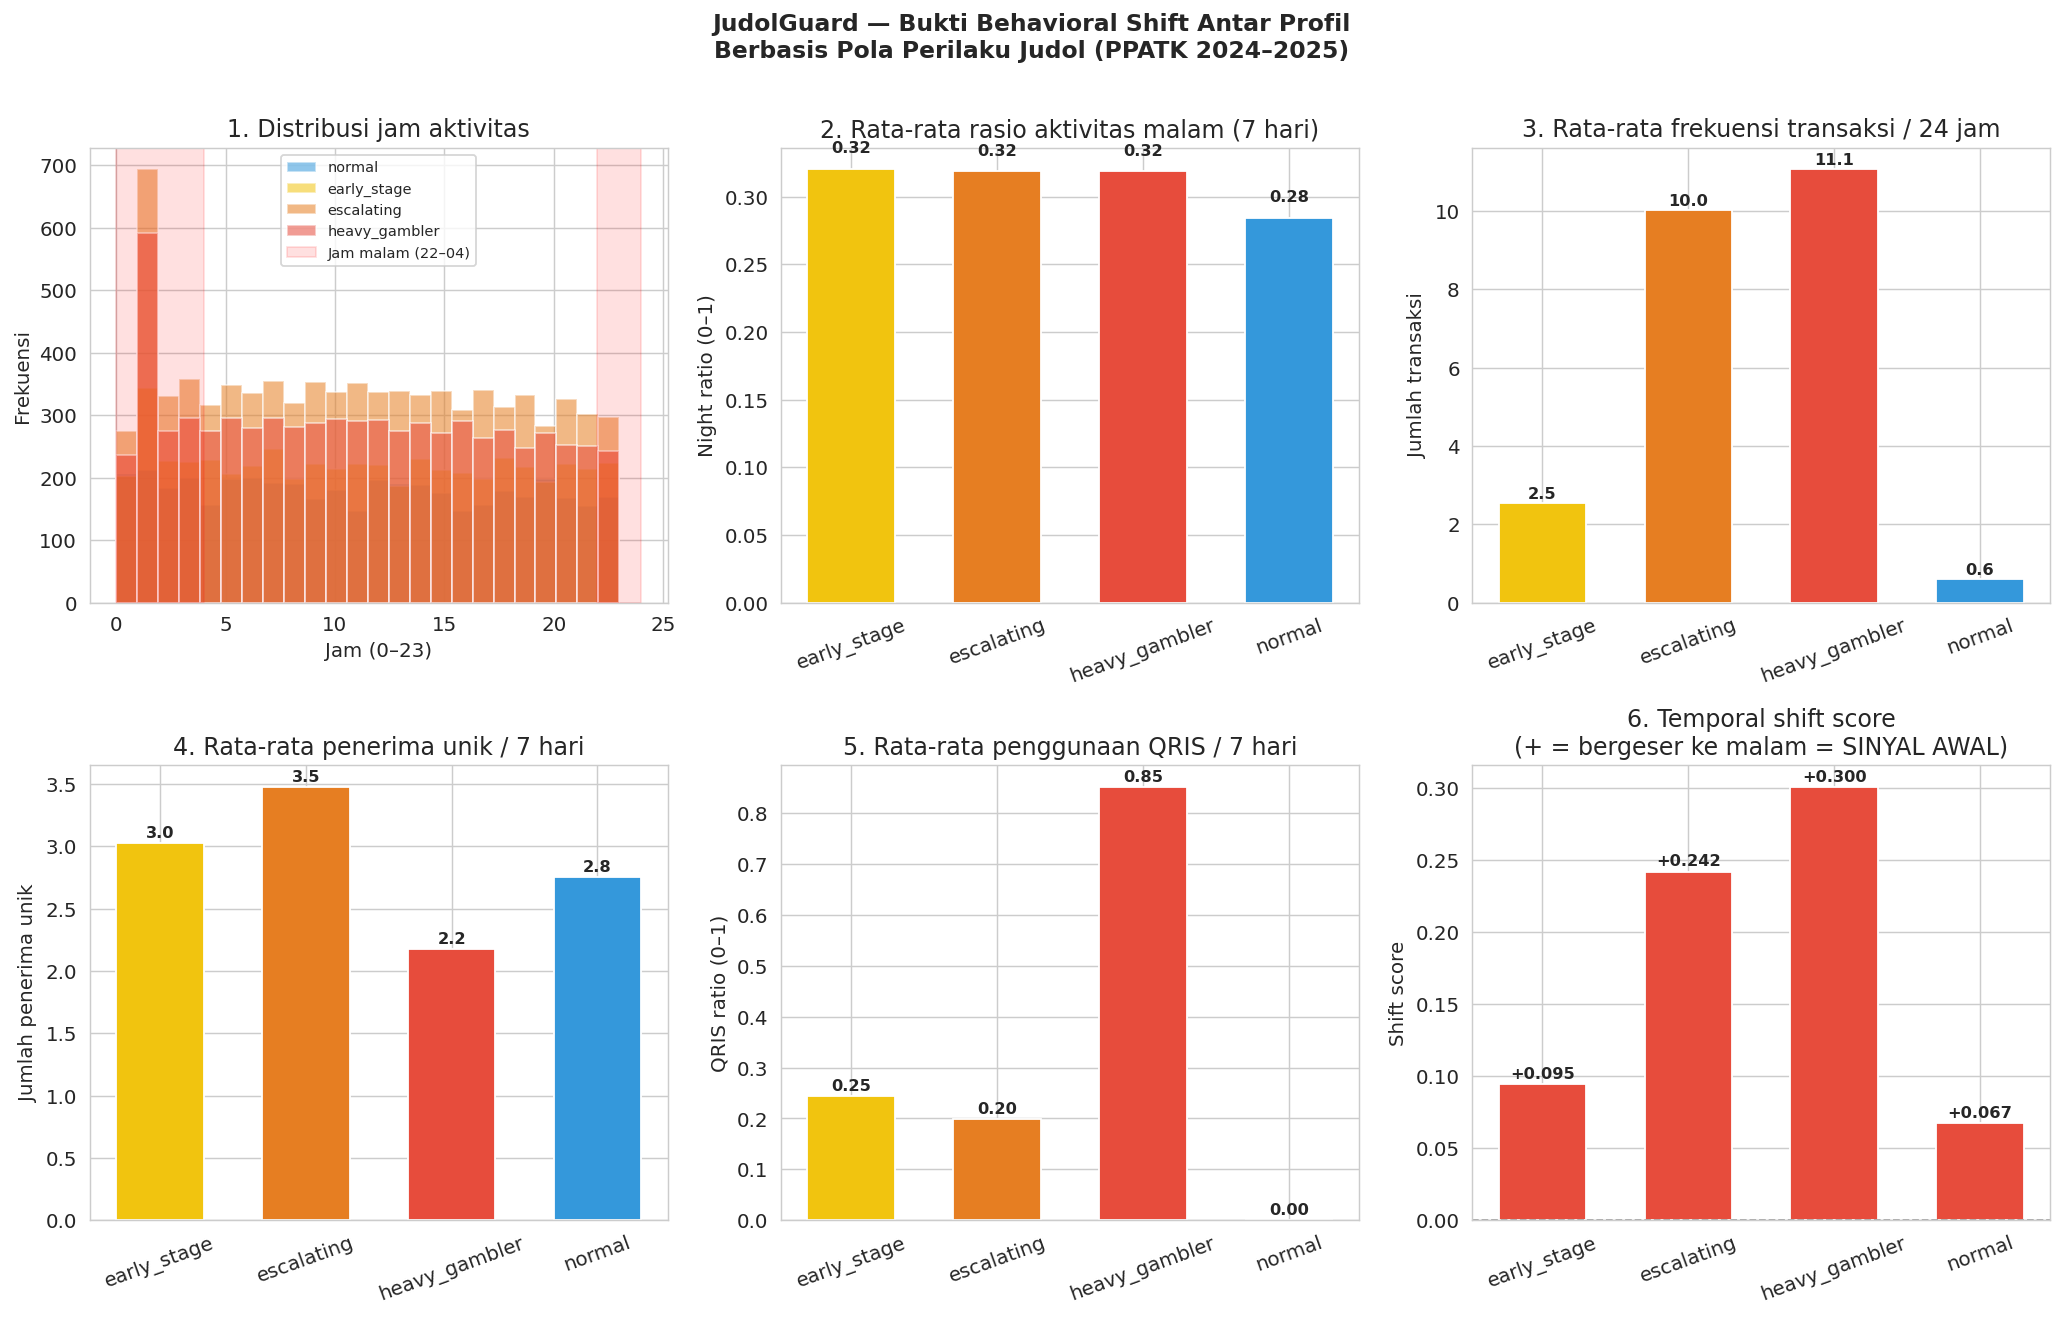

In [ ]:
#Setup Visualisasi
import os

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

fig.suptitle(
    'JudolGuard — Bukti Behavioral Shift Antar Profil\n'
    'Berbasis Pola Perilaku Judol (PPATK 2024–2025)',
    fontsize=13,
    fontweight='bold',
    y=1.01
)

for p, c in PALETTE.items():
    data = df[df['profile'] == p]['hour_of_day']
    axes[0,0].hist(data, bins=24, alpha=0.55, label=p, color=c, range=(0,23))
axes[0,0].axvspan(22, 24, alpha=0.12, color='red')
axes[0,0].axvspan(0, 4, alpha=0.12, color='red', label='Jam malam (22–04)')
axes[0,0].set_title('1. Distribusi jam aktivitas')
axes[0,0].set_xlabel('Jam (0–23)')
axes[0,0].set_ylabel('Frekuensi')
axes[0,0].legend(fontsize=8)

# Calculate means_night
means_night = df.groupby('profile')['night_ratio_7d'].mean()
bars = axes[0,1].bar(
    means_night.index, means_night.values,
    color=[PALETTE[p] for p in means_night.index], edgecolor='white', width=0.6
)
axes[0,1].set_title('2. Rata-rata rasio aktivitas malam (7 hari)')
axes[0,1].set_ylabel('Night ratio (0–1)')
axes[0,1].tick_params(axis='x', rotation=20)
# Tambahkan angka di atas bar
for bar, val in zip(bars, means_night.values):
    axes[0,1].text(
        bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
        f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold'
    )

means_tx = df.groupby('profile')['tx_count_24h'].mean()
bars2 = axes[0,2].bar(
    means_tx.index, means_tx.values,
    color=[PALETTE[p] for p in means_tx.index], edgecolor='white', width=0.6
)
axes[0,2].set_title('3. Rata-rata frekuensi transaksi / 24 jam')
axes[0,2].set_ylabel('Jumlah transaksi')
axes[0,2].tick_params(axis='x', rotation=20)
for bar, val in zip(bars2, means_tx.values):
    axes[0,2].text(
        bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
        f'{val:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold'
    )

means_recv = df.groupby('profile')['unique_recv_7d'].mean()
bars3 = axes[1,0].bar(
    means_recv.index, means_recv.values,
    color=[PALETTE[p] for p in means_recv.index], edgecolor='white', width=0.6
)
axes[1,0].set_title('4. Rata-rata penerima unik / 7 hari')
axes[1,0].set_ylabel('Jumlah penerima unik')
axes[1,0].tick_params(axis='x', rotation=20)
for bar, val in zip(bars3, means_recv.values):
    axes[1,0].text(
        bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
        f'{val:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold'
    )


means_qris = df.groupby('profile')['qris_ratio_7d'].mean()
bars4 = axes[1,1].bar(
    means_qris.index, means_qris.values,
    color=[PALETTE[p] for p in means_qris.index], edgecolor='white', width=0.6
)
axes[1,1].set_title('5. Rata-rata penggunaan QRIS / 7 hari')
axes[1,1].set_ylabel('QRIS ratio (0–1)')
axes[1,1].tick_params(axis='x', rotation=20)
for bar, val in zip(bars4, means_qris.values):
    axes[1,1].text(
        bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
        f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold'
    )

    means_shift = df.groupby('profile')['temporal_shift'].mean()
colors_shift = ['#e74c3c' if v > 0.02 else '#27ae60' for v in means_shift.values]
bars5 = axes[1,2].bar(
    means_shift.index, means_shift.values,
    color=colors_shift, edgecolor='white', width=0.6
)
axes[1,2].axhline(0, color='gray', linewidth=1, linestyle='--', alpha=0.7)
axes[1,2].set_title('6. Temporal shift score\n(+ = bergeser ke malam = SINYAL AWAL)')
axes[1,2].set_ylabel('Shift score')
axes[1,2].tick_params(axis='x', rotation=20)
for bar, val in zip(bars5, means_shift.values):
    offset = 0.002 if val >= 0 else -0.008
    axes[1,2].text(
        bar.get_x() + bar.get_width()/2, val + offset,
        f'{val:+.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold'
    )

plt.tight_layout()

# Create the 'data' directory if it doesn't exist
os.makedirs('data', exist_ok=True)

plt.savefig('data/eda_behavioral_shift.png', dpi=150, bbox_inches='tight')
plt.show()

SECTION 3 — TIMELINE AKUN ESCALATING (MONEY SLIDE)

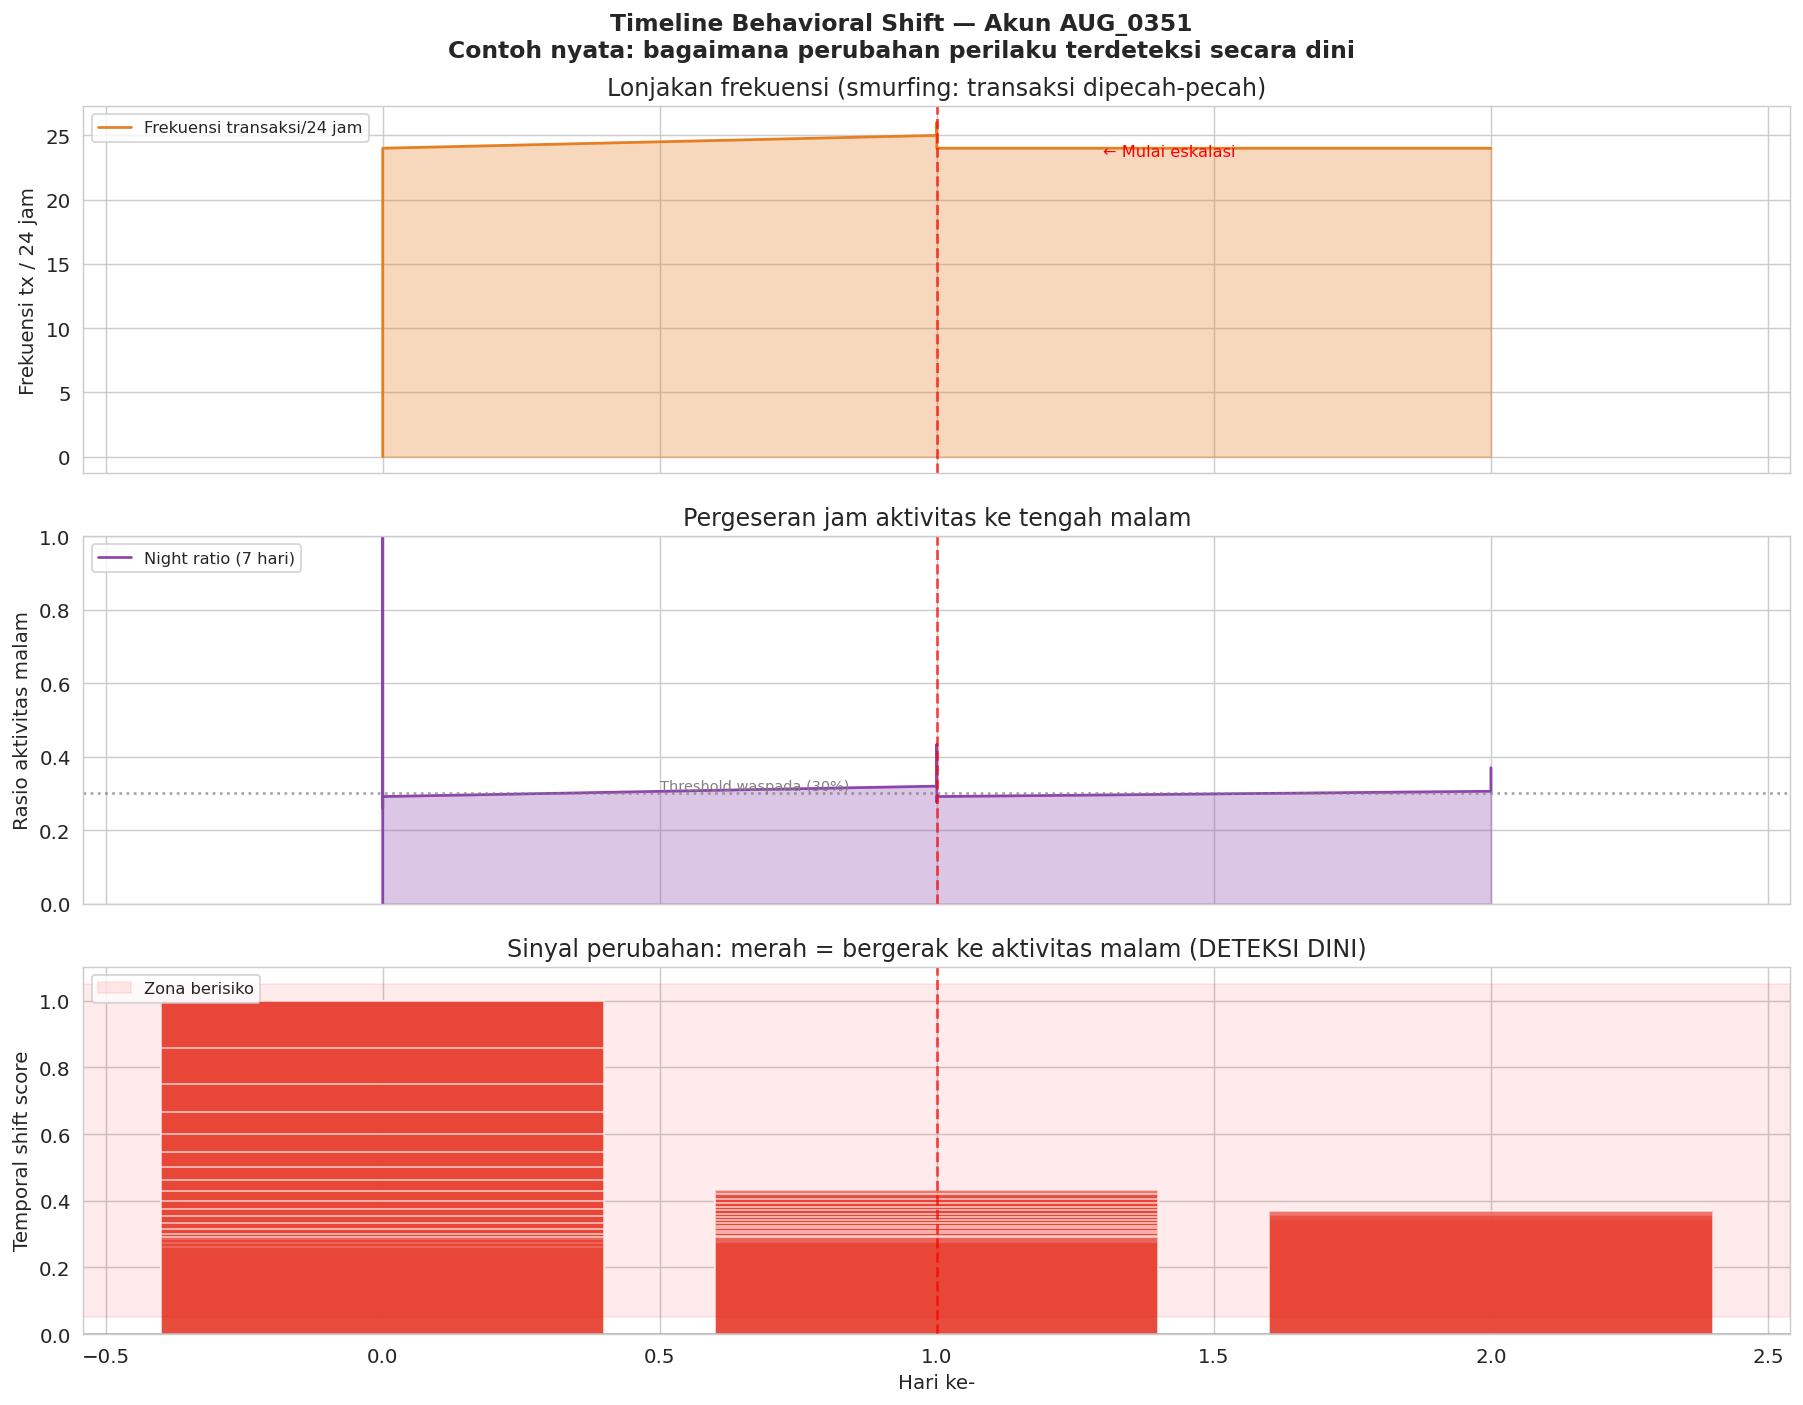


 Timeline chart tersimpan: data/eda_timeline_escalating.png


In [ ]:
#Memilih Sampel Akun
#Ambil akun escalating dengan riwayat terpanjang (paling banyak transaksi)
escalating_accs = df[df['profile'] == 'escalating']
best_acc = escalating_accs.groupby('account_id').size().idxmax()
acc_data = escalating_accs[escalating_accs['account_id'] == best_acc].sort_values('day')

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
fig.suptitle(
    f'Timeline Behavioral Shift — Akun {best_acc}\n'
    f'Contoh nyata: bagaimana perubahan perilaku terdeteksi secara dini',
    fontsize=13, fontweight='bold'
)

#Plot 1: Frekuensi transaksi per hari
#Visualisasi Frekuensi Transaksi
ax1.fill_between(acc_data['day'], acc_data['tx_count_24h'],
                  alpha=0.3, color='#e67e22')
ax1.plot(acc_data['day'], acc_data['tx_count_24h'],
          color='#e67e22', linewidth=1.5, label='Frekuensi transaksi/24 jam')

shift_day = acc_data['day'].quantile(0.6)
ax1.axvline(shift_day, color='red', linestyle='--', alpha=0.7, linewidth=1.5)
ax1.text(shift_day + 0.3, acc_data['tx_count_24h'].max() * 0.9,
          '← Mulai eskalasi', color='red', fontsize=9)
ax1.set_ylabel('Frekuensi tx / 24 jam')
ax1.legend(loc='upper left', fontsize=9)
ax1.set_title('Lonjakan frekuensi (smurfing: transaksi dipecah-pecah)')

#Plot 2: Night ratio per 7 hari
#Analisis Aktivitas Malam
ax2.fill_between(acc_data['day'], acc_data['night_ratio_7d'],
                  alpha=0.3, color='#8e44ad')
ax2.plot(acc_data['day'], acc_data['night_ratio_7d'],
          color='#8e44ad', linewidth=1.5, label='Night ratio (7 hari)')
ax2.axhline(0.3, color='gray', linestyle=':', alpha=0.7)
ax2.text(0.5, 0.31, 'Threshold waspada (30%)', fontsize=8, color='gray')
ax2.axvline(shift_day, color='red', linestyle='--', alpha=0.7, linewidth=1.5)
ax2.set_ylabel('Rasio aktivitas malam')
ax2.set_ylim(0, 1)
ax2.legend(loc='upper left', fontsize=9)
ax2.set_title('Pergeseran jam aktivitas ke tengah malam')

#Plot 3: Temporal shift score
colors_ts = ['#e74c3c' if v > 0 else '#27ae60'
              for v in acc_data['temporal_shift']]
ax3.bar(acc_data['day'], acc_data['temporal_shift'],
         color=colors_ts, alpha=0.7, width=0.8)
ax3.axhline(0, color='black', linewidth=0.8)
ax3.axvline(shift_day, color='red', linestyle='--', alpha=0.7, linewidth=1.5)
ax3.set_ylabel('Temporal shift score')
ax3.set_xlabel('Hari ke-')
ax3.set_title('Sinyal perubahan: merah = bergerak ke aktivitas malam (DETEKSI DINI)')

#Menambahkan zona keterangan
ax3.axhspan(0.05, acc_data['temporal_shift'].max() + 0.05,
             alpha=0.08, color='red', label='Zona berisiko')
ax3.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('data/eda_timeline_escalating.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n Timeline chart tersimpan: data/eda_timeline_escalating.png")


SECTION 4 — HEATMAP KORELASI FITUR vs LABEL


In [ ]:
# Pilih hanya kolom numerik yang relevan
numeric_cols = [
    'is_at_risk', 'is_night', 'night_ratio_7d', 'night_ratio_14d',
    'temporal_shift', 'amount_log', 'amount_vs_avg_7d', 'total_amount_7d',
    'tx_count_24h', 'tx_count_7d', 'burst_score',
    'unique_recv_7d', 'unique_recv_24h', 'qris_ratio_7d',
    'drain_cycle_flag', 'dormant_flag'
]

corr_matrix = df[numeric_cols].corr()



In [ ]:
# Fokus pada korelasi dengan label is_at_risk
corr_with_label = corr_matrix['is_at_risk'].drop('is_at_risk').dropna().sort_values(key=abs, ascending=False)

print("  KORELASI FITUR vs IS_AT_RISK (diurutkan)\n")
for feat, corr in corr_with_label.items():
    bar = '█' * int(abs(corr) * 20)
    sign = '+' if corr > 0 else '-'
    print(f"  {feat:<25} {sign}{abs(corr):.4f}  {bar}")

  KORELASI FITUR vs IS_AT_RISK (diurutkan)

  amount_log                -0.5593  ███████████
  unique_recv_24h           +0.5310  ██████████
  tx_count_7d               +0.5259  ██████████
  tx_count_24h              +0.5232  ██████████
  qris_ratio_7d             +0.4931  █████████
  burst_score               +0.4298  ████████
  drain_cycle_flag          +0.3732  ███████
  total_amount_7d           +0.3072  ██████
  temporal_shift            +0.2997  █████
  amount_vs_avg_7d          -0.2127  ████
  night_ratio_7d            +0.0332  
  night_ratio_14d           +0.0205  
  unique_recv_7d            -0.0105  
  is_night                  +0.0075  


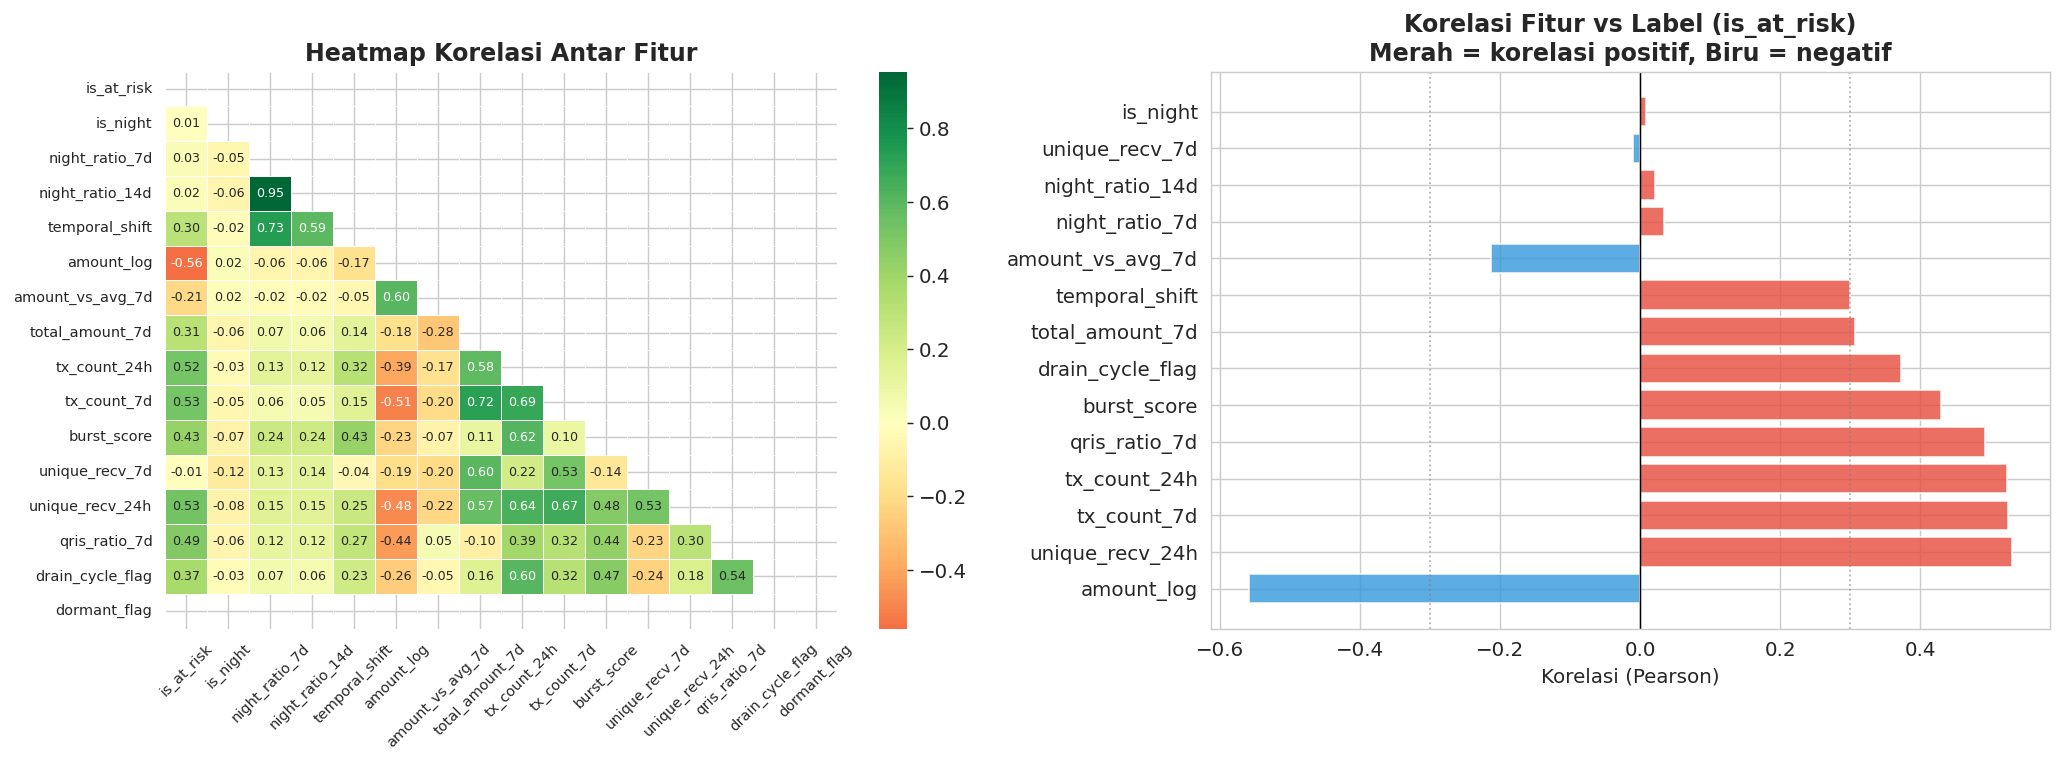


 Correlation chart tersimpan: data/eda_correlation.png

 Fitur dengan |korelasi| > 0.1 (akan masuk ke model):
  ['amount_log', 'unique_recv_24h', 'tx_count_7d', 'tx_count_24h', 'qris_ratio_7d', 'burst_score', 'drain_cycle_flag', 'total_amount_7d', 'temporal_shift', 'amount_vs_avg_7d']


In [ ]:
# Plot heatmap
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap full
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, ax=ax1,
    annot_kws={'size': 7}, linewidths=0.3
)
ax1.set_title('Heatmap Korelasi Antar Fitur', fontweight='bold')
ax1.tick_params(axis='x', rotation=45, labelsize=8)
ax1.tick_params(axis='y', labelsize=8)

# Bar chart korelasi vs label
colors_corr = ['#e74c3c' if v > 0 else '#3498db' for v in corr_with_label.values]
ax2.barh(corr_with_label.index, corr_with_label.values,
          color=colors_corr, edgecolor='white', alpha=0.8)
ax2.axvline(0, color='black', linewidth=0.8)
ax2.axvline(0.3,  color='gray', linestyle=':', alpha=0.6, linewidth=1)
ax2.axvline(-0.3, color='gray', linestyle=':', alpha=0.6, linewidth=1)
ax2.set_title('Korelasi Fitur vs Label (is_at_risk)\nMerah = korelasi positif, Biru = negatif',
               fontweight='bold')
ax2.set_xlabel('Korelasi (Pearson)')

plt.tight_layout()
plt.savefig('data/eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n Correlation chart tersimpan: data/eda_correlation.png")

# Identifikasi fitur terbaik untuk masuk ke model
top_features = corr_with_label[abs(corr_with_label) > 0.1].index.tolist()
print(f"\n Fitur dengan |korelasi| > 0.1 (akan masuk ke model):")
print(f"  {top_features}")

SECTION 5 — RINGKASAN STATISTIK PER PROFIL

In [ ]:
summary = df.groupby('profile').agg(
    n_akun=('account_id', 'nunique'),
    n_transaksi=('step', 'count'),
    avg_night_ratio=('night_ratio_7d', 'mean'),
    avg_tx_per_day=('tx_count_24h', 'mean'),
    avg_unique_recv=('unique_recv_7d', 'mean'),
    avg_qris_ratio=('qris_ratio_7d', 'mean'),
    avg_temporal_shift=('temporal_shift', 'mean'),
    pct_at_risk=('is_at_risk', 'mean')
).round(3)

summary['pct_at_risk'] = (summary['pct_at_risk'] * 100).round(1).astype(str) + '%'
summary.to_csv('data/eda_summary.csv')

print("RINGKASAN STATISTIK PER PROFIL")
print(summary.to_string())
print(f"\n Summary tersimpan: data/eda_summary.csv")

print("  FASE 3 SELESAI")
print("  Output:")
print("    data/eda_behavioral_shift.png")
print("    data/eda_timeline_escalating.png")
print("    data/eda_correlation.png")
print("    data/eda_summary.csv")
print("\n  Next: Fase 4 — Modeling (04_modeling.py)")

RINGKASAN STATISTIK PER PROFIL
               n_akun  n_transaksi  avg_night_ratio  avg_tx_per_day  avg_unique_recv  avg_qris_ratio  avg_temporal_shift pct_at_risk
profile                                                                                                                             
early_stage       155         5301            0.320           2.533            3.028           0.245               0.095        0.0%
escalating        155         8215            0.319          10.009            3.474           0.198               0.242      100.0%
heavy_gambler     155         6913            0.319          11.056            2.175           0.851               0.300      100.0%
normal            155         4309            0.284           0.597            2.755           0.000               0.067        0.0%

 Summary tersimpan: data/eda_summary.csv
  FASE 3 SELESAI
  Output:
    data/eda_behavioral_shift.png
    data/eda_timeline_escalating.png
    data/eda_correlation.png
  